<a href="https://colab.research.google.com/github/Prajjwal2123/internship-assignments/blob/main/week3_Prajjwal_sharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import pandas as pd

zip_path = "/content/drive/MyDrive/archive (4).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

df = pd.read_csv("/content/dataset/Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
from sklearn.preprocessing import StandardScaler

# Create a classification target
median_gdp = df['gdpp'].median()

df['target'] = (df['gdpp'] > median_gdp).astype(int)

X = df.drop(['country', 'target'], axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        17
           1       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



In [6]:
!pip install xgboost -q

In [7]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



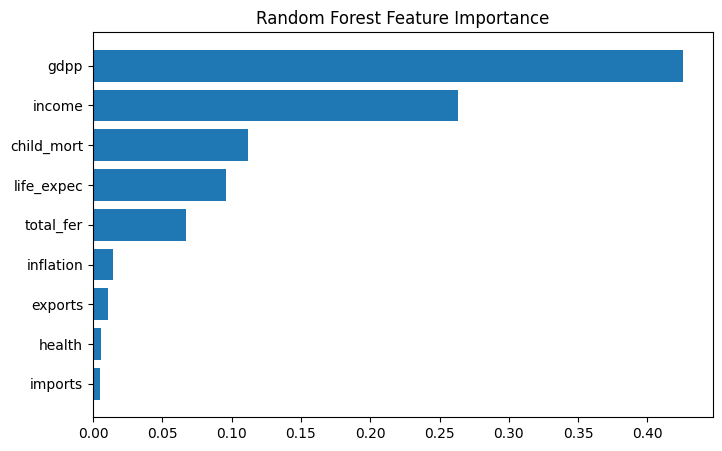

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))
plt.barh(
    importance['Feature'],
    importance['Importance']
)
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.show()

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

df[['country', 'KMeans_Cluster']].head()

,country,KMeans_Cluster
0,Afghanistan,2
1,Albania,0
2,Algeria,0
3,Angola,2
4,Antigua and Barbuda,0


In [10]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

df[['country', 'DBSCAN_Cluster']].head()

,country,DBSCAN_Cluster
0,Afghanistan,0
1,Albania,0
2,Algeria,0
3,Angola,-1
4,Antigua and Barbuda,0


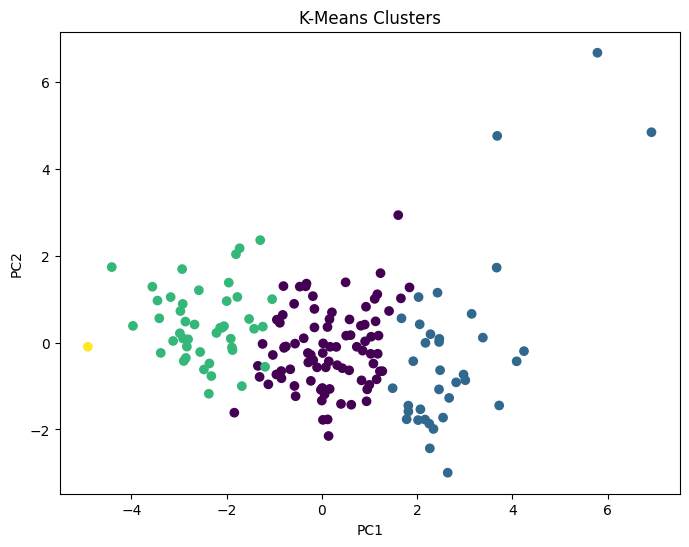

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['KMeans_Cluster']
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters")
plt.show()